## Imports

In [1]:
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import setuptools
import packaging
import pkg_resources
pkg_resources.packaging = packaging
import torch.optim as optim
import torch.nn as nn
import clip 
from sklearn.model_selection import train_test_split
import random
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.pyplot as plt
from peft import LoraConfig, get_peft_model

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) 
seed_everything(42)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26440\4038038913.py:7: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
c:\Users\LENOVO\Documents\GitHub\Socrates_CLIP\.venv_apod\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## DataLoaders

In [6]:
class APODDataset(Dataset):
    def __init__(self, dataframe, preprocess):
        self.df = dataframe.reset_index(drop=True) 
        self.preprocess = preprocess

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = self.preprocess(Image.open(row['image_path']))
        caption = str(row['phil_caption']) if 'phil_caption' in row else str(row['caption'])
        text = clip.tokenize(caption, truncate=True)[0]
        
        return image, text

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
model, preprocess = clip.load("ViT-B/32", device=device, jit=False)

df = pd.read_csv("dataset_clip_philosophical.csv")


train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)

val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


train_ds = APODDataset(train_df, preprocess)
val_ds = APODDataset(val_df, preprocess)
test_ds = APODDataset(test_df, preprocess)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

cuda
Train: 8615 | Val: 1077 | Test: 1077


## CLIP

### Full Fine-Tunning

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Entrenando en: {device}")

model, preprocess = clip.load("ViT-B/32", device=device, jit=False)

if device == "cpu":
    model.float()
else:
    model.float() 

model.train()

Entrenando en: cuda


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

Iniciando entrenamiento en cuda...


Epoch 0 [Train]: 100%|██████████| 270/270 [35:22<00:00,  7.86s/it, loss=1.1] 



>> Epoch 0 Finalizada | Train Loss: 1.9580 | Val Loss: 1.9554



Epoch 1 [Train]: 100%|██████████| 270/270 [35:55<00:00,  7.98s/it, loss=1.25] 



>> Epoch 1 Finalizada | Train Loss: 1.2691 | Val Loss: 2.1176



...


>> Epoch 2 Finalizada | Train Loss: 0.7680 | Val Loss: 2.5171



Epoch 3 [Train]: 100%|██████████| 270/270 [33:44<00:00,  7.50s/it, loss=0.168] 



>> Epoch 3 Finalizada | Train Loss: 0.4334 | Val Loss: 3.1300



Epoch 4 [Train]: 100%|██████████| 270/270 [33:46<00:00,  7.51s/it, loss=6.16e-5]



>> Epoch 4 Finalizada | Train Loss: 0.2358 | Val Loss: 3.4118

Ejecutando evaluación final en el Test Set...
RESULTADO FINAL - Test Loss: 3.3752
Modelo guardado exitosamente.


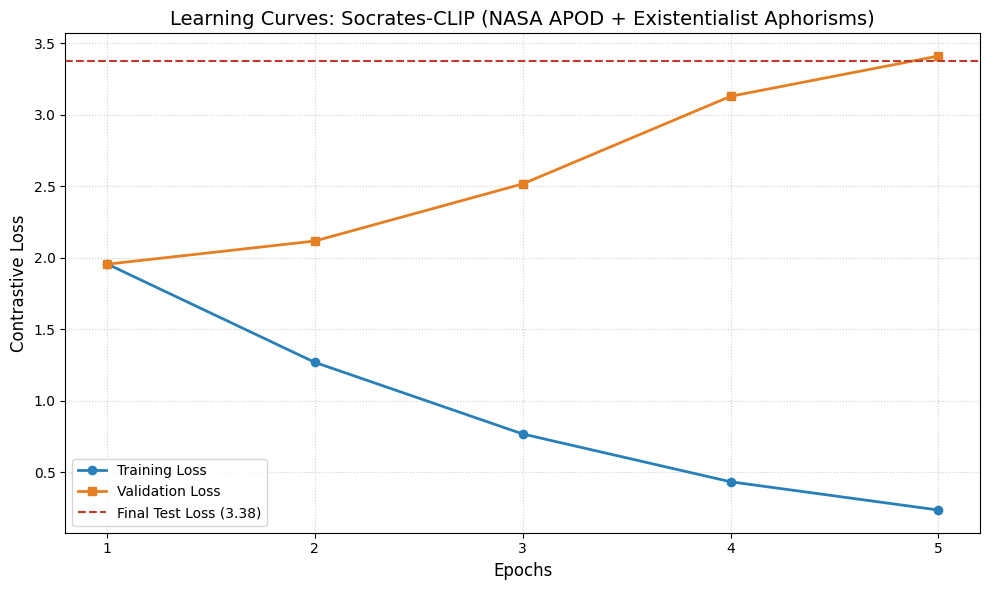

In [ ]:
epochs = 5
optimizer = optim.AdamW(model.parameters(), lr=5e-6, betas=(0.9, 0.98), eps=1e-6, weight_decay=0.2)
loss_img = nn.CrossEntropyLoss()
loss_txt = nn.CrossEntropyLoss()

train_losses = []
val_losses = []

print(f"Iniciando entrenamiento en {device}...")

for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]")
    for images, texts in pbar:
        images = images.to(device)
        texts = texts.to(device)

        optimizer.zero_grad()

        logits_per_image, logits_per_text = model(images, texts)
        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)

        loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_train_loss += loss.item()
        pbar.set_postfix({"loss": loss.item()})

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)


    model.eval()
    total_val_loss = 0
    
    with torch.no_grad():
        for images, texts in val_loader:
            images = images.to(device)
            texts = texts.to(device)
            
            logits_per_image, logits_per_text = model(images, texts)
            ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
            
            val_loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
            total_val_loss += val_loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"\n>> Epoch {epoch} Finalizada | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}\n")

print("Ejecutando evaluación final en el Test Set...")
model.eval()
total_test_loss = 0
with torch.no_grad():
    for images, texts in test_loader:
        images = images.to(device)
        texts = texts.to(device)
        logits_per_image, logits_per_text = model(images, texts)
        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
        loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
        total_test_loss += loss.item()

final_test_loss = total_test_loss / len(test_loader)
print(f"RESULTADO FINAL - Test Loss: {final_test_loss:.4f}")

torch.save(model.state_dict(), "socrates_clip_weights.pt")
print("Modelo guardado exitosamente.")

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', color='#2980b9', marker='o', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='#e67e22', marker='s', linewidth=2)

plt.axhline(y=final_test_loss, color='#c0392b', linestyle='--', label=f'Final Test Loss ({final_test_loss:.2f})')

plt.title('Learning Curves: Socrates-CLIP (NASA APOD + Existentialist Aphorisms)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Contrastive Loss', fontsize=12)
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("socrates_clip_learning_curves.png", dpi=300)
plt.show()

### LoRA

In [4]:
for name, module in model.named_modules():
    if "attn" in name or "proj" in name:
        print(name)

visual.transformer.resblocks.0.attn
visual.transformer.resblocks.0.attn.out_proj
visual.transformer.resblocks.0.mlp.c_proj
visual.transformer.resblocks.1.attn
visual.transformer.resblocks.1.attn.out_proj
visual.transformer.resblocks.1.mlp.c_proj
visual.transformer.resblocks.2.attn
visual.transformer.resblocks.2.attn.out_proj
visual.transformer.resblocks.2.mlp.c_proj
visual.transformer.resblocks.3.attn
visual.transformer.resblocks.3.attn.out_proj
visual.transformer.resblocks.3.mlp.c_proj
visual.transformer.resblocks.4.attn
visual.transformer.resblocks.4.attn.out_proj
visual.transformer.resblocks.4.mlp.c_proj
visual.transformer.resblocks.5.attn
visual.transformer.resblocks.5.attn.out_proj
visual.transformer.resblocks.5.mlp.c_proj
visual.transformer.resblocks.6.attn
visual.transformer.resblocks.6.attn.out_proj
visual.transformer.resblocks.6.mlp.c_proj
visual.transformer.resblocks.7.attn
visual.transformer.resblocks.7.attn.out_proj
visual.transformer.resblocks.7.mlp.c_proj
visual.transform

#### 5 Epochs + 1e-4 LR

Iniciando entrenamiento con Adaptador de Bajo Rango en cuda...
Parámetros entrenables: 32768


Epoch 0 [Train]: 100%|██████████| 270/270 [00:39<00:00,  6.87it/s, loss=2.84]



>> Epoch 0 Finalizada | Train Loss: 22.0551 | Val Loss: 16.6369



Epoch 1 [Train]: 100%|██████████| 270/270 [00:41<00:00,  6.48it/s, loss=15.8]



>> Epoch 1 Finalizada | Train Loss: 15.2755 | Val Loss: 13.8514



...


>> Epoch 2 Finalizada | Train Loss: 12.7058 | Val Loss: 11.6000



Epoch 3 [Train]: 100%|██████████| 270/270 [00:45<00:00,  5.95it/s, loss=5]   



>> Epoch 3 Finalizada | Train Loss: 10.5772 | Val Loss: 9.7777



Epoch 4 [Train]: 100%|██████████| 270/270 [00:42<00:00,  6.30it/s, loss=6.27]



>> Epoch 4 Finalizada | Train Loss: 8.9648 | Val Loss: 8.3967

Ejecutando evaluación final en el Test Set...
RESULTADO FINAL - Test Loss: 8.4199
Pesos del adaptador guardados exitosamente.


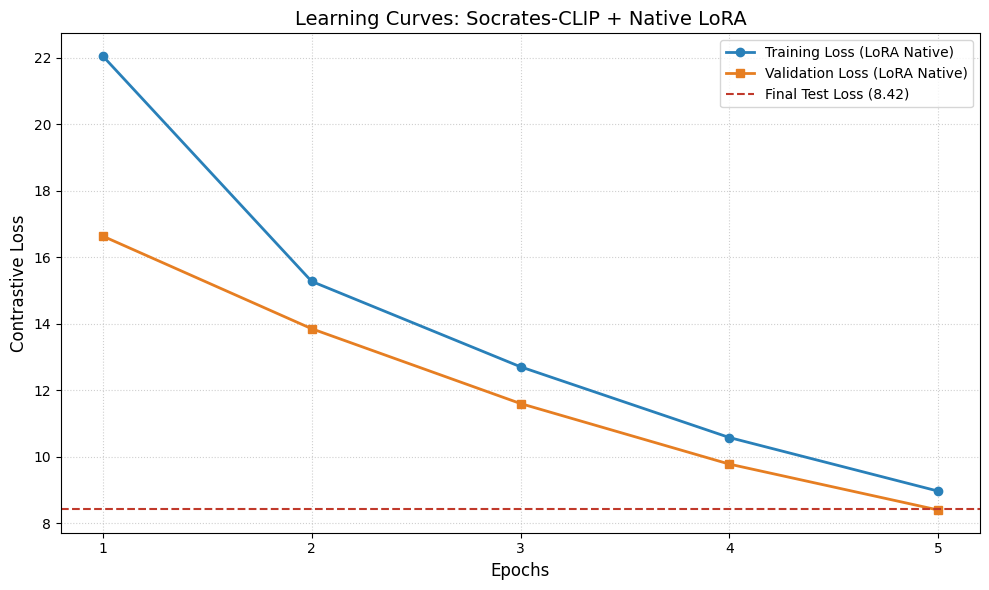

In [ ]:
class CLIPLoraAdapter(nn.Module):
    def __init__(self, embed_dim, r=16):
        super().__init__()
        self.image_lora = nn.Sequential(
            nn.Linear(embed_dim, r, bias=False),
            nn.Linear(r, embed_dim, bias=False)
        )
        self.text_lora = nn.Sequential(
            nn.Linear(embed_dim, r, bias=False),
            nn.Linear(r, embed_dim, bias=False)
        )
        nn.init.zeros_(self.image_lora[1].weight)
        nn.init.zeros_(self.text_lora[1].weight)

    def forward(self, image_features, text_features):
        img_f32 = image_features.float()
        txt_f32 = text_features.float()
        
        idx_img = img_f32 + self.image_lora(img_f32)
        idx_txt = txt_f32 + self.text_lora(txt_f32)
        
        idx_img = idx_img / idx_img.norm(dim=-1, keepdim=True)
        idx_txt = idx_txt / idx_txt.norm(dim=-1, keepdim=True)
        return idx_img, txt_f32  

model.eval()
for param in model.parameters():
    param.requires_grad = False

embed_dim = model.text_projection.shape[1] 
adapter = CLIPLoraAdapter(embed_dim=embed_dim, r=16).to(device)

logit_scale = model.logit_scale.exp().item()

epochs = 5
optimizer = optim.AdamW(adapter.parameters(), lr=1e-4, weight_decay=0.1)
loss_img = nn.CrossEntropyLoss()
loss_txt = nn.CrossEntropyLoss()

train_losses = []
val_losses = []

print(f"Iniciando entrenamiento con Adaptador de Bajo Rango en {device}...")
print(f"Parámetros entrenables: {sum(p.numel() for p in adapter.parameters() if p.requires_grad)}")

for epoch in range(epochs):
    adapter.train()
    total_train_loss = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]")
    for images, texts in pbar:
        images = images.to(device)
        texts = texts.to(device)

        optimizer.zero_grad()

        with torch.no_grad():
            image_features = model.encode_image(images)
            text_features = model.encode_text(texts)

        adapted_images, adapted_texts = adapter(image_features, text_features)

        logits_per_image = logit_scale * torch.matmul(adapted_images, adapted_texts.t())
        logits_per_text = logits_per_image.t()
        
        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
        loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        pbar.set_postfix({"loss": loss.item()})

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    adapter.eval()
    total_val_loss = 0
    with torch.no_grad():
        for images, texts in val_loader:
            images = images.to(device)
            texts = texts.to(device)
            
            image_features = model.encode_image(images)
            text_features = model.encode_text(texts)
            
            adapted_images, adapted_texts = adapter(image_features, text_features)
            logits_per_image = logit_scale * torch.matmul(adapted_images, adapted_texts.t())
            logits_per_text = logits_per_image.t()
            
            ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
            val_loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
            total_val_loss += val_loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    print(f"\n>> Epoch {epoch} Finalizada | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}\n")


print("Ejecutando evaluación final en el Test Set...")
adapter.eval()
total_test_loss = 0
with torch.no_grad():
    for images, texts in test_loader:
        images = images.to(device)
        texts = texts.to(device)
        image_features = model.encode_image(images)
        text_features = model.encode_text(texts)
        adapted_images, adapted_texts = adapter(image_features, text_features)
        logits_per_image = logit_scale * torch.matmul(adapted_images, adapted_texts.t())
        logits_per_text = logits_per_image.t()
        
        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
        loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
        total_test_loss += loss.item()

final_test_loss = total_test_loss / len(test_loader)
print(f"RESULTADO FINAL - Test Loss: {final_test_loss:.4f}")

torch.save(adapter.state_dict(), "socrates_clip_lora_adapter.pt")
print("Pesos del adaptador guardados exitosamente.")

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss (LoRA Native)', color='#2980b9', marker='o', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss (LoRA Native)', color='#e67e22', marker='s', linewidth=2)
plt.axhline(y=final_test_loss, color='#c0392b', linestyle='--', label=f'Final Test Loss ({final_test_loss:.2f})')
plt.title('Learning Curves: Socrates-CLIP + Native LoRA', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Contrastive Loss', fontsize=12)
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("socrates_clip_native_lora_curves.png", dpi=300)
plt.show()

#### 10 epochs + 1e-4 LR

Iniciando entrenamiento con Adaptador de Bajo Rango en cuda...
Parámetros entrenables: 32768


Epoch 0 [Train]: 100%|██████████| 270/270 [00:43<00:00,  6.16it/s, loss=2.58]



>> Epoch 0 Finalizada | Train Loss: 22.2026 | Val Loss: 16.5786



Epoch 1 [Train]: 100%|██████████| 270/270 [00:46<00:00,  5.86it/s, loss=0.0544]



>> Epoch 1 Finalizada | Train Loss: 15.3252 | Val Loss: 13.7842



...


>> Epoch 7 Finalizada | Train Loss: 6.2305 | Val Loss: 6.1983



Epoch 8 [Train]: 100%|██████████| 270/270 [00:35<00:00,  7.56it/s, loss=1.02]



>> Epoch 8 Finalizada | Train Loss: 5.7463 | Val Loss: 5.8145



Epoch 9 [Train]: 100%|██████████| 270/270 [00:36<00:00,  7.32it/s, loss=0.974]



>> Epoch 9 Finalizada | Train Loss: 5.3281 | Val Loss: 5.4905

Ejecutando evaluación final en el Test Set...
RESULTADO FINAL - Test Loss: 5.4605
Pesos del adaptador guardados exitosamente.


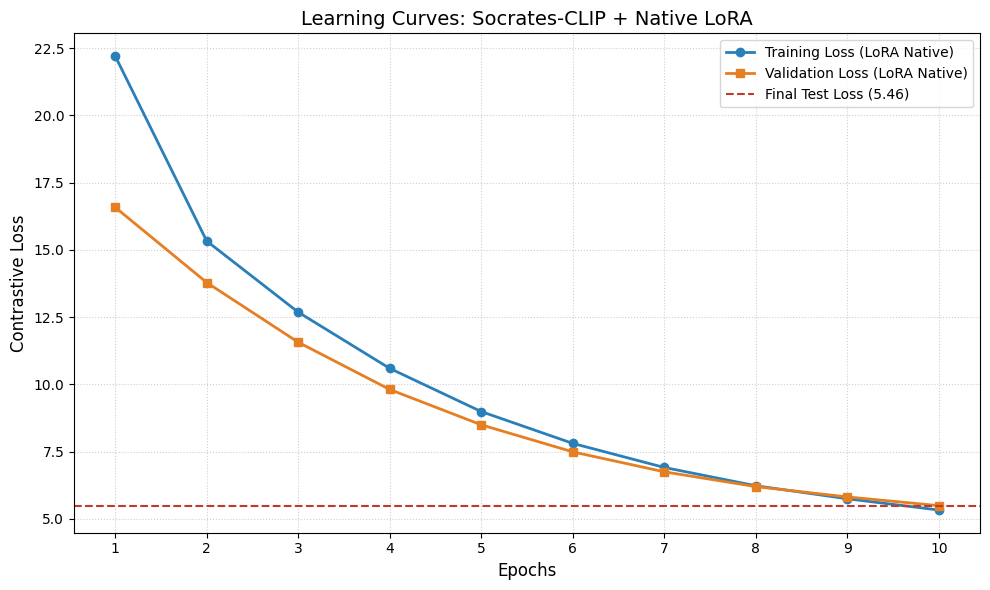

In [18]:
class CLIPLoraAdapter(nn.Module):
    def __init__(self, embed_dim, r=16):
        super().__init__()
        self.image_lora = nn.Sequential(
            nn.Linear(embed_dim, r, bias=False),
            nn.Linear(r, embed_dim, bias=False)
        )
        self.text_lora = nn.Sequential(
            nn.Linear(embed_dim, r, bias=False),
            nn.Linear(r, embed_dim, bias=False)
        )
        nn.init.zeros_(self.image_lora[1].weight)
        nn.init.zeros_(self.text_lora[1].weight)

    def forward(self, image_features, text_features):
        img_f32 = image_features.float()
        txt_f32 = text_features.float()
        
        idx_img = img_f32 + self.image_lora(img_f32)
        idx_txt = txt_f32 + self.text_lora(txt_f32)
        
        idx_img = idx_img / idx_img.norm(dim=-1, keepdim=True)
        idx_txt = idx_txt / idx_txt.norm(dim=-1, keepdim=True)
        return idx_img, txt_f32  

model.eval()
for param in model.parameters():
    param.requires_grad = False

embed_dim = model.text_projection.shape[1] 
adapter = CLIPLoraAdapter(embed_dim=embed_dim, r=16).to(device)

logit_scale = model.logit_scale.exp().item()

epochs = 10
optimizer = optim.AdamW(adapter.parameters(), lr=1e-4, weight_decay=0.1)
loss_img = nn.CrossEntropyLoss()
loss_txt = nn.CrossEntropyLoss()

train_losses = []
val_losses = []

print(f"Iniciando entrenamiento con Adaptador de Bajo Rango en {device}...")
print(f"Parámetros entrenables: {sum(p.numel() for p in adapter.parameters() if p.requires_grad)}")

for epoch in range(epochs):
    adapter.train()
    total_train_loss = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]")
    for images, texts in pbar:
        images = images.to(device)
        texts = texts.to(device)

        optimizer.zero_grad()

        with torch.no_grad():
            image_features = model.encode_image(images)
            text_features = model.encode_text(texts)

        adapted_images, adapted_texts = adapter(image_features, text_features)

        logits_per_image = logit_scale * torch.matmul(adapted_images, adapted_texts.t())
        logits_per_text = logits_per_image.t()
        
        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
        loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        pbar.set_postfix({"loss": loss.item()})

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    adapter.eval()
    total_val_loss = 0
    with torch.no_grad():
        for images, texts in val_loader:
            images = images.to(device)
            texts = texts.to(device)
            
            image_features = model.encode_image(images)
            text_features = model.encode_text(texts)
            
            adapted_images, adapted_texts = adapter(image_features, text_features)
            logits_per_image = logit_scale * torch.matmul(adapted_images, adapted_texts.t())
            logits_per_text = logits_per_image.t()
            
            ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
            val_loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
            total_val_loss += val_loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    print(f"\n>> Epoch {epoch} Finalizada | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}\n")


print("Ejecutando evaluación final en el Test Set...")
adapter.eval()
total_test_loss = 0
with torch.no_grad():
    for images, texts in test_loader:
        images = images.to(device)
        texts = texts.to(device)
        image_features = model.encode_image(images)
        text_features = model.encode_text(texts)
        adapted_images, adapted_texts = adapter(image_features, text_features)
        logits_per_image = logit_scale * torch.matmul(adapted_images, adapted_texts.t())
        logits_per_text = logits_per_image.t()
        
        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
        loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
        total_test_loss += loss.item()

final_test_loss = total_test_loss / len(test_loader)
print(f"RESULTADO FINAL - Test Loss: {final_test_loss:.4f}")

torch.save(adapter.state_dict(), "socrates_clip_lora_adapter.pt")
print("Pesos del adaptador guardados exitosamente.")

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss (LoRA Native)', color='#2980b9', marker='o', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss (LoRA Native)', color='#e67e22', marker='s', linewidth=2)
plt.axhline(y=final_test_loss, color='#c0392b', linestyle='--', label=f'Final Test Loss ({final_test_loss:.2f})')
plt.title('Learning Curves: Socrates-CLIP + Native LoRA', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Contrastive Loss', fontsize=12)
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("socrates_clip_native_lora_curves.png", dpi=300)
plt.show()

#### 10 epochs + 3e-4 LR

Iniciando entrenamiento con Adaptador de Bajo Rango en cuda...
Parámetros entrenables: 32768


Epoch 0 [Train]: 100%|██████████| 270/270 [00:36<00:00,  7.48it/s, loss=13.2]



>> Epoch 0 Finalizada | Train Loss: 17.5760 | Val Loss: 12.1494



Epoch 1 [Train]: 100%|██████████| 270/270 [00:35<00:00,  7.64it/s, loss=3.44]



>> Epoch 1 Finalizada | Train Loss: 9.7968 | Val Loss: 8.0684



...


>> Epoch 7 Finalizada | Train Loss: 3.7924 | Val Loss: 4.0556



Epoch 8 [Train]: 100%|██████████| 270/270 [00:35<00:00,  7.58it/s, loss=2.21]



>> Epoch 8 Finalizada | Train Loss: 3.5875 | Val Loss: 3.8328



Epoch 9 [Train]: 100%|██████████| 270/270 [00:35<00:00,  7.58it/s, loss=1.96]



>> Epoch 9 Finalizada | Train Loss: 3.4061 | Val Loss: 3.6807

Ejecutando evaluación final en el Test Set...
RESULTADO FINAL - Test Loss: 3.4720
Pesos del adaptador guardados exitosamente.


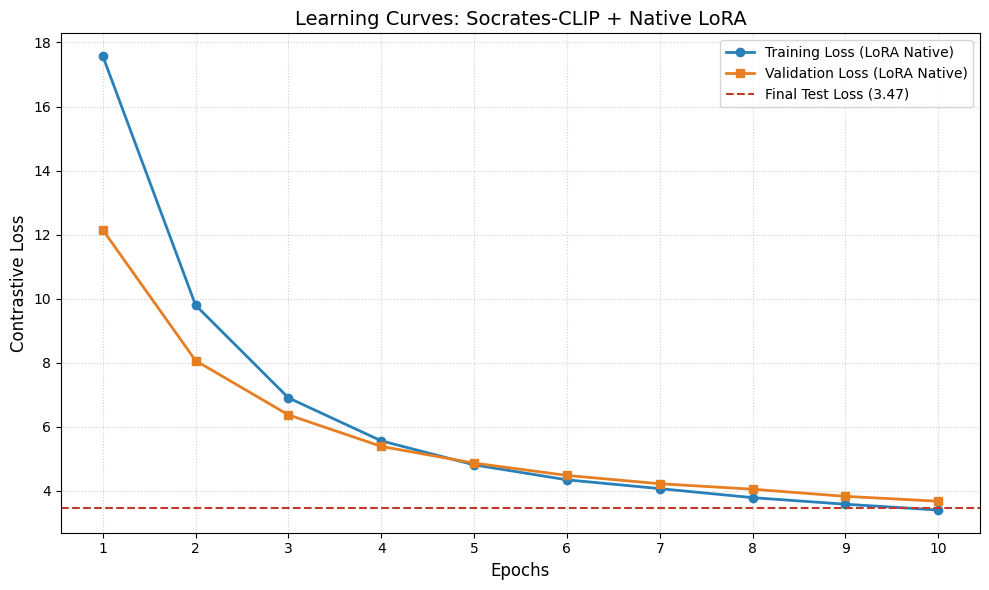

In [21]:
class CLIPLoraAdapter(nn.Module):
    def __init__(self, embed_dim, r=16):
        super().__init__()
        self.image_lora = nn.Sequential(
            nn.Linear(embed_dim, r, bias=False),
            nn.Linear(r, embed_dim, bias=False)
        )
        self.text_lora = nn.Sequential(
            nn.Linear(embed_dim, r, bias=False),
            nn.Linear(r, embed_dim, bias=False)
        )
        nn.init.zeros_(self.image_lora[1].weight)
        nn.init.zeros_(self.text_lora[1].weight)

    def forward(self, image_features, text_features):
        img_f32 = image_features.float()
        txt_f32 = text_features.float()
        
        idx_img = img_f32 + self.image_lora(img_f32)
        idx_txt = txt_f32 + self.text_lora(txt_f32)
        
        idx_img = idx_img / idx_img.norm(dim=-1, keepdim=True)
        idx_txt = idx_txt / idx_txt.norm(dim=-1, keepdim=True)
        return idx_img, txt_f32  

model.eval()
for param in model.parameters():
    param.requires_grad = False

embed_dim = model.text_projection.shape[1] 
adapter = CLIPLoraAdapter(embed_dim=embed_dim, r=16).to(device)

logit_scale = model.logit_scale.exp().item()

epochs = 10
optimizer = optim.AdamW(adapter.parameters(), lr=3e-4, weight_decay=0.1)
loss_img = nn.CrossEntropyLoss()
loss_txt = nn.CrossEntropyLoss()

train_losses = []
val_losses = []

print(f"Iniciando entrenamiento con Adaptador de Bajo Rango en {device}...")
print(f"Parámetros entrenables: {sum(p.numel() for p in adapter.parameters() if p.requires_grad)}")

for epoch in range(epochs):
    adapter.train()
    total_train_loss = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]")
    for images, texts in pbar:
        images = images.to(device)
        texts = texts.to(device)

        optimizer.zero_grad()

        with torch.no_grad():
            image_features = model.encode_image(images)
            text_features = model.encode_text(texts)

        adapted_images, adapted_texts = adapter(image_features, text_features)

        logits_per_image = logit_scale * torch.matmul(adapted_images, adapted_texts.t())
        logits_per_text = logits_per_image.t()
        
        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
        loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        pbar.set_postfix({"loss": loss.item()})

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    adapter.eval()
    total_val_loss = 0
    with torch.no_grad():
        for images, texts in val_loader:
            images = images.to(device)
            texts = texts.to(device)
            
            image_features = model.encode_image(images)
            text_features = model.encode_text(texts)
            
            adapted_images, adapted_texts = adapter(image_features, text_features)
            logits_per_image = logit_scale * torch.matmul(adapted_images, adapted_texts.t())
            logits_per_text = logits_per_image.t()
            
            ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
            val_loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
            total_val_loss += val_loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    print(f"\n>> Epoch {epoch} Finalizada | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}\n")


print("Ejecutando evaluación final en el Test Set...")
adapter.eval()
total_test_loss = 0
with torch.no_grad():
    for images, texts in test_loader:
        images = images.to(device)
        texts = texts.to(device)
        image_features = model.encode_image(images)
        text_features = model.encode_text(texts)
        adapted_images, adapted_texts = adapter(image_features, text_features)
        logits_per_image = logit_scale * torch.matmul(adapted_images, adapted_texts.t())
        logits_per_text = logits_per_image.t()
        
        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
        loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
        total_test_loss += loss.item()

final_test_loss = total_test_loss / len(test_loader)
print(f"RESULTADO FINAL - Test Loss: {final_test_loss:.4f}")

torch.save(adapter.state_dict(), "socrates_clip_lora_adapter.pt")
print("Pesos del adaptador guardados exitosamente.")

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss (LoRA Native)', color='#2980b9', marker='o', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss (LoRA Native)', color='#e67e22', marker='s', linewidth=2)
plt.axhline(y=final_test_loss, color='#c0392b', linestyle='--', label=f'Final Test Loss ({final_test_loss:.2f})')
plt.title('Learning Curves: Socrates-CLIP + Native LoRA', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Contrastive Loss', fontsize=12)
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("socrates_clip_native_lora_curves.png", dpi=300)
plt.show()

#### 15 epochs + 3e-4 LR

Iniciando entrenamiento con Adaptador de Bajo Rango en cuda...
Parámetros entrenables: 32768


Epoch 0 [Train]: 100%|██████████| 270/270 [00:45<00:00,  5.94it/s, loss=10.1]



>> Epoch 0 Finalizada | Train Loss: 17.2668 | Val Loss: 12.0599



Epoch 1 [Train]: 100%|██████████| 270/270 [00:35<00:00,  7.59it/s, loss=2.98]



>> Epoch 1 Finalizada | Train Loss: 9.7640 | Val Loss: 7.8540



...


>> Epoch 12 Finalizada | Train Loss: 3.1068 | Val Loss: 3.2937



Epoch 13 [Train]: 100%|██████████| 270/270 [00:35<00:00,  7.61it/s, loss=1.13]



>> Epoch 13 Finalizada | Train Loss: 3.0099 | Val Loss: 3.2128



Epoch 14 [Train]: 100%|██████████| 270/270 [00:36<00:00,  7.36it/s, loss=3.45]



>> Epoch 14 Finalizada | Train Loss: 2.9678 | Val Loss: 3.1655

Ejecutando evaluación final en el Test Set...
RESULTADO FINAL - Test Loss: 2.9744
Pesos del adaptador guardados exitosamente.


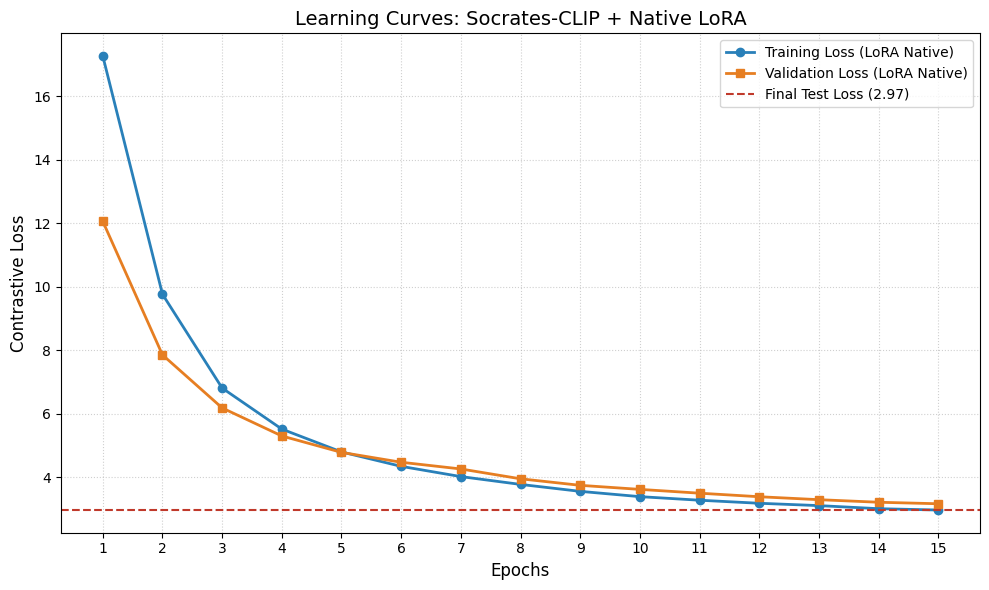

In [23]:
class CLIPLoraAdapter(nn.Module):
    def __init__(self, embed_dim, r=16):
        super().__init__()
        self.image_lora = nn.Sequential(
            nn.Linear(embed_dim, r, bias=False),
            nn.Linear(r, embed_dim, bias=False)
        )
        self.text_lora = nn.Sequential(
            nn.Linear(embed_dim, r, bias=False),
            nn.Linear(r, embed_dim, bias=False)
        )
        nn.init.zeros_(self.image_lora[1].weight)
        nn.init.zeros_(self.text_lora[1].weight)

    def forward(self, image_features, text_features):
        img_f32 = image_features.float()
        txt_f32 = text_features.float()
        
        idx_img = img_f32 + self.image_lora(img_f32)
        idx_txt = txt_f32 + self.text_lora(txt_f32)
        
        idx_img = idx_img / idx_img.norm(dim=-1, keepdim=True)
        idx_txt = idx_txt / idx_txt.norm(dim=-1, keepdim=True)
        return idx_img, txt_f32  

model.eval()
for param in model.parameters():
    param.requires_grad = False

embed_dim = model.text_projection.shape[1] 
adapter = CLIPLoraAdapter(embed_dim=embed_dim, r=16).to(device)

logit_scale = model.logit_scale.exp().item()

epochs = 15
optimizer = optim.AdamW(adapter.parameters(), lr=3e-4, weight_decay=0.1)
loss_img = nn.CrossEntropyLoss()
loss_txt = nn.CrossEntropyLoss()

train_losses = []
val_losses = []

print(f"Iniciando entrenamiento con Adaptador de Bajo Rango en {device}...")
print(f"Parámetros entrenables: {sum(p.numel() for p in adapter.parameters() if p.requires_grad)}")

for epoch in range(epochs):
    adapter.train()
    total_train_loss = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]")
    for images, texts in pbar:
        images = images.to(device)
        texts = texts.to(device)

        optimizer.zero_grad()

        with torch.no_grad():
            image_features = model.encode_image(images)
            text_features = model.encode_text(texts)

        adapted_images, adapted_texts = adapter(image_features, text_features)

        logits_per_image = logit_scale * torch.matmul(adapted_images, adapted_texts.t())
        logits_per_text = logits_per_image.t()
        
        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
        loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        pbar.set_postfix({"loss": loss.item()})

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    adapter.eval()
    total_val_loss = 0
    with torch.no_grad():
        for images, texts in val_loader:
            images = images.to(device)
            texts = texts.to(device)
            
            image_features = model.encode_image(images)
            text_features = model.encode_text(texts)
            
            adapted_images, adapted_texts = adapter(image_features, text_features)
            logits_per_image = logit_scale * torch.matmul(adapted_images, adapted_texts.t())
            logits_per_text = logits_per_image.t()
            
            ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
            val_loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
            total_val_loss += val_loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    print(f"\n>> Epoch {epoch} Finalizada | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}\n")


print("Ejecutando evaluación final en el Test Set...")
adapter.eval()
total_test_loss = 0
with torch.no_grad():
    for images, texts in test_loader:
        images = images.to(device)
        texts = texts.to(device)
        image_features = model.encode_image(images)
        text_features = model.encode_text(texts)
        adapted_images, adapted_texts = adapter(image_features, text_features)
        logits_per_image = logit_scale * torch.matmul(adapted_images, adapted_texts.t())
        logits_per_text = logits_per_image.t()
        
        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
        loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
        total_test_loss += loss.item()

final_test_loss = total_test_loss / len(test_loader)
print(f"RESULTADO FINAL - Test Loss: {final_test_loss:.4f}")

torch.save(adapter.state_dict(), "socrates_clip_lora_adapter.pt")
print("Pesos del adaptador guardados exitosamente.")

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss (LoRA Native)', color='#2980b9', marker='o', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss (LoRA Native)', color='#e67e22', marker='s', linewidth=2)
plt.axhline(y=final_test_loss, color='#c0392b', linestyle='--', label=f'Final Test Loss ({final_test_loss:.2f})')
plt.title('Learning Curves: Socrates-CLIP + Native LoRA', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Contrastive Loss', fontsize=12)
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("socrates_clip_native_lora_curves.png", dpi=300)
plt.show()

#### 20 epochs + 5e-4 LR

Iniciando entrenamiento con Adaptador de Bajo Rango en cuda...
Parámetros entrenables: 32768


Epoch 0 [Train]: 100%|██████████| 270/270 [00:42<00:00,  6.35it/s, loss=7.03]



>> Epoch 0 Finalizada | Train Loss: 15.2732 | Val Loss: 9.4912



Epoch 1 [Train]: 100%|██████████| 270/270 [00:37<00:00,  7.19it/s, loss=3.72]



>> Epoch 1 Finalizada | Train Loss: 7.5607 | Val Loss: 6.2886



...


>> Epoch 17 Finalizada | Train Loss: 2.6312 | Val Loss: 2.8182



Epoch 18 [Train]: 100%|██████████| 270/270 [00:36<00:00,  7.38it/s, loss=1.26]



>> Epoch 18 Finalizada | Train Loss: 2.6043 | Val Loss: 2.7700



Epoch 19 [Train]: 100%|██████████| 270/270 [00:42<00:00,  6.33it/s, loss=1.32]



>> Epoch 19 Finalizada | Train Loss: 2.5788 | Val Loss: 2.8567

Ejecutando evaluación final en el Test Set...
RESULTADO FINAL - Test Loss: 2.7351
Pesos del adaptador guardados exitosamente.


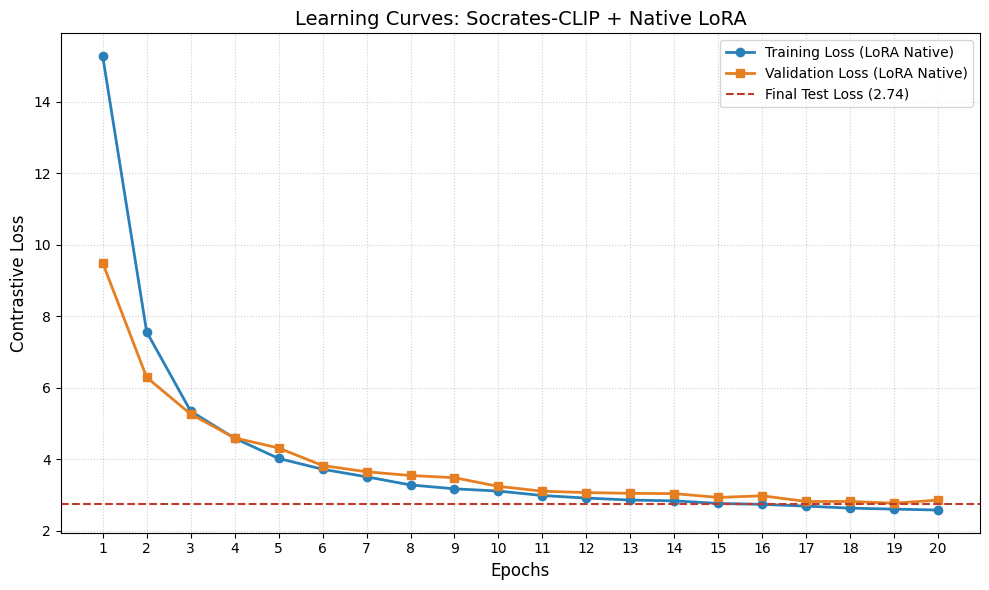

In [ ]:
class CLIPLoraAdapter(nn.Module):
    def __init__(self, embed_dim, r=16):
        super().__init__()
        self.image_lora = nn.Sequential(
            nn.Linear(embed_dim, r, bias=False),
            nn.Linear(r, embed_dim, bias=False)
        )
        self.text_lora = nn.Sequential(
            nn.Linear(embed_dim, r, bias=False),
            nn.Linear(r, embed_dim, bias=False)
        )
        nn.init.zeros_(self.image_lora[1].weight)
        nn.init.zeros_(self.text_lora[1].weight)

    def forward(self, image_features, text_features):
        img_f32 = image_features.float()
        txt_f32 = text_features.float()
        
        idx_img = img_f32 + self.image_lora(img_f32)
        idx_txt = txt_f32 + self.text_lora(txt_f32)
        
        idx_img = idx_img / idx_img.norm(dim=-1, keepdim=True)
        idx_txt = idx_txt / idx_txt.norm(dim=-1, keepdim=True)
        return idx_img, txt_f32  

model.eval()
for param in model.parameters():
    param.requires_grad = False

embed_dim = model.text_projection.shape[1] 
adapter = CLIPLoraAdapter(embed_dim=embed_dim, r=16).to(device)

logit_scale = model.logit_scale.exp().item()

epochs = 20
optimizer = optim.AdamW(adapter.parameters(), lr=5e-4, weight_decay=0.1)
loss_img = nn.CrossEntropyLoss()
loss_txt = nn.CrossEntropyLoss()

train_losses = []
val_losses = []

print(f"Iniciando entrenamiento con Adaptador de Bajo Rango en {device}...")
print(f"Parámetros entrenables: {sum(p.numel() for p in adapter.parameters() if p.requires_grad)}")

for epoch in range(epochs):
    adapter.train()
    total_train_loss = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]")
    for images, texts in pbar:
        images = images.to(device)
        texts = texts.to(device)

        optimizer.zero_grad()

        with torch.no_grad():
            image_features = model.encode_image(images)
            text_features = model.encode_text(texts)

        adapted_images, adapted_texts = adapter(image_features, text_features)

        logits_per_image = logit_scale * torch.matmul(adapted_images, adapted_texts.t())
        logits_per_text = logits_per_image.t()
        
        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
        loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        pbar.set_postfix({"loss": loss.item()})

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    adapter.eval()
    total_val_loss = 0
    with torch.no_grad():
        for images, texts in val_loader:
            images = images.to(device)
            texts = texts.to(device)
            
            image_features = model.encode_image(images)
            text_features = model.encode_text(texts)
            
            adapted_images, adapted_texts = adapter(image_features, text_features)
            logits_per_image = logit_scale * torch.matmul(adapted_images, adapted_texts.t())
            logits_per_text = logits_per_image.t()
            
            ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
            val_loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
            total_val_loss += val_loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    print(f"\n>> Epoch {epoch} Finalizada | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}\n")


print("Ejecutando evaluación final en el Test Set...")
adapter.eval()
total_test_loss = 0
with torch.no_grad():
    for images, texts in test_loader:
        images = images.to(device)
        texts = texts.to(device)
        image_features = model.encode_image(images)
        text_features = model.encode_text(texts)
        adapted_images, adapted_texts = adapter(image_features, text_features)
        logits_per_image = logit_scale * torch.matmul(adapted_images, adapted_texts.t())
        logits_per_text = logits_per_image.t()
        
        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
        loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
        total_test_loss += loss.item()

final_test_loss = total_test_loss / len(test_loader)
print(f"RESULTADO FINAL - Test Loss: {final_test_loss:.4f}")

torch.save(adapter.state_dict(), "socrates_clip_lora_adapter.pt")
print("Pesos del adaptador guardados exitosamente.")

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss (LoRA Native)', color='#2980b9', marker='o', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss (LoRA Native)', color='#e67e22', marker='s', linewidth=2)
plt.axhline(y=final_test_loss, color='#c0392b', linestyle='--', label=f'Final Test Loss ({final_test_loss:.2f})')
plt.title('Learning Curves: Socrates-CLIP + Native LoRA', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Contrastive Loss', fontsize=12)
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("socrates_clip_native_lora_curves.png", dpi=300)
plt.show()

In [28]:
def evaluate_metrics(model, dataloader, device, adapter=None):
    model.eval()
    if adapter is not None:
        adapter.eval()
        
    all_image_features = []
    all_text_features = []

    with torch.no_grad():
        for images, texts in dataloader:
            images = images.to(device)
            texts = texts.to(device)

            image_features = model.encode_image(images)
            text_features = model.encode_text(texts)

            if adapter is not None:
                image_features, text_features = adapter(image_features, text_features)
            else:
                image_features /= image_features.norm(dim=-1, keepdim=True)
                text_features /= text_features.norm(dim=-1, keepdim=True)

            all_image_features.append(image_features)
            all_text_features.append(text_features)

    all_image_features = torch.cat(all_image_features)
    all_text_features = torch.cat(all_text_features)

    sim_matrix = (all_image_features @ all_text_features.T).cpu()

    ranks = []
    for i in range(sim_matrix.size(0)):
        sims = sim_matrix[i]
        sorted_indices = torch.argsort(sims, descending=True)
        rank = (sorted_indices == i).nonzero(as_tuple=True)[0].item()
        ranks.append(rank)

    ranks = torch.tensor(ranks)
    
    r1 = (ranks < 1).float().mean().item() * 100
    r5 = (ranks < 5).float().mean().item() * 100
    r10 = (ranks < 10).float().mean().item() * 100
    p1 = (ranks < 1).float().mean().item() * 100 
    p5 = ((ranks < 5).float() / 5.0).mean().item() * 100
    p10 = ((ranks < 10).float() / 10.0).mean().item() * 100
    mrr = (1.0 / (ranks.float() + 1)).mean().item()

    return {"R@1": r1, "R@5": r5, "R@10": r10, "MRR": mrr, "p@1": p1, "p@5": p5, "p@10": p10}

Iniciando entrenamiento con Adaptador de Bajo Rango en cuda...
Parámetros entrenables: 32768


Epoch 0 [Train]: 100%|██████████| 270/270 [00:53<00:00,  5.01it/s, loss=6.17]



>> Epoch 0 Finalizada | Train Loss: 20.3637 | Val Loss: 15.3589

-> Val R@1: 6.31% | Val R@5: 18.29%


Epoch 1 [Train]: 100%|██████████| 270/270 [00:46<00:00,  5.83it/s, loss=3.1] 



>> Epoch 1 Finalizada | Train Loss: 13.6261 | Val Loss: 11.8741

-> Val R@1: 6.96% | Val R@5: 17.83%


...


>> Epoch 17 Finalizada | Train Loss: 3.3050 | Val Loss: 3.6036

-> Val R@1: 2.32% | Val R@5: 9.84%


Epoch 18 [Train]: 100%|██████████| 270/270 [00:48<00:00,  5.55it/s, loss=1.7] 



>> Epoch 18 Finalizada | Train Loss: 3.2567 | Val Loss: 3.5198

-> Val R@1: 2.41% | Val R@5: 10.49%


Epoch 19 [Train]: 100%|██████████| 270/270 [00:46<00:00,  5.81it/s, loss=1.26]



>> Epoch 19 Finalizada | Train Loss: 3.2141 | Val Loss: 3.4897

-> Val R@1: 2.14% | Val R@5: 9.47%
Ejecutando evaluación final en el Test Set...
RESULTADO FINAL - Test Loss: 3.2422

Métricas en Test Set:
Recall@1: 5.20% | Recall@5: 14.21% | Recall@10: 19.7772| MRR: 0.1024 | Precision@1: 5.1996| Precision@5: 2.8412| Precision@10: 1.9777
Pesos del adaptador guardados exitosamente.


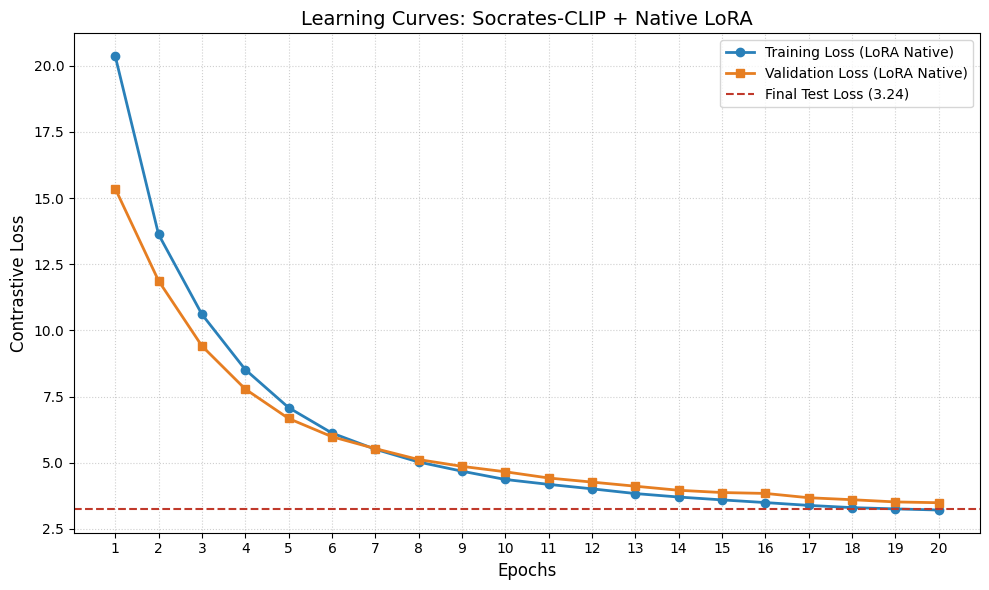

In [29]:
class CLIPLoraAdapter(nn.Module):
    def __init__(self, embed_dim, r=16, alpha=4):
        super().__init__()
        self.image_lora = nn.Sequential(
            nn.Linear(embed_dim, r, bias=False),
            nn.Linear(r, embed_dim, bias=False)
        )
        self.text_lora = nn.Sequential(
            nn.Linear(embed_dim, r, bias=False),
            nn.Linear(r, embed_dim, bias=False)
        )
        nn.init.zeros_(self.image_lora[1].weight)
        nn.init.zeros_(self.text_lora[1].weight)

        self.scaling = alpha / r

    def forward(self, image_features, text_features):
        img_f32 = image_features.float()
        txt_f32 = text_features.float()
        
        idx_img = img_f32 + (self.image_lora(img_f32)*self.scaling)
        idx_txt = txt_f32 + (self.text_lora(txt_f32)*self.scaling)
        
        idx_img = idx_img / idx_img.norm(dim=-1, keepdim=True)
        idx_txt = idx_txt / idx_txt.norm(dim=-1, keepdim=True)
        return idx_img, txt_f32  

model.eval()
for param in model.parameters():
    param.requires_grad = False

embed_dim = model.text_projection.shape[1] 
adapter = CLIPLoraAdapter(embed_dim=embed_dim, r=16, alpha=4).to(device)

logit_scale = model.logit_scale.exp().item()

epochs = 20
optimizer = optim.AdamW(adapter.parameters(), lr=3e-4, weight_decay=0.1)
loss_img = nn.CrossEntropyLoss()
loss_txt = nn.CrossEntropyLoss()

train_losses = []
val_losses = []

print(f"Iniciando entrenamiento con Adaptador de Bajo Rango en {device}...")
print(f"Parámetros entrenables: {sum(p.numel() for p in adapter.parameters() if p.requires_grad)}")

for epoch in range(epochs):
    adapter.train()
    total_train_loss = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]")
    for images, texts in pbar:
        images = images.to(device)
        texts = texts.to(device)

        optimizer.zero_grad()

        with torch.no_grad():
            image_features = model.encode_image(images)
            text_features = model.encode_text(texts)

        adapted_images, adapted_texts = adapter(image_features, text_features)

        logits_per_image = logit_scale * torch.matmul(adapted_images, adapted_texts.t())
        logits_per_text = logits_per_image.t()
        
        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
        loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        pbar.set_postfix({"loss": loss.item()})

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    adapter.eval()
    total_val_loss = 0
    with torch.no_grad():
        for images, texts in val_loader:
            images = images.to(device)
            texts = texts.to(device)
            
            image_features = model.encode_image(images)
            text_features = model.encode_text(texts)
            
            adapted_images, adapted_texts = adapter(image_features, text_features)
            logits_per_image = logit_scale * torch.matmul(adapted_images, adapted_texts.t())
            logits_per_text = logits_per_image.t()
            
            ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
            val_loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
            total_val_loss += val_loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    print(f"\n>> Epoch {epoch} Finalizada | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}\n")
    epoch_metrics = evaluate_metrics(model, val_loader, device, adapter=adapter)
    print(f"-> Val R@1: {epoch_metrics['R@1']:.2f}% | Val R@5: {epoch_metrics['R@5']:.2f}%")


print("Ejecutando evaluación final en el Test Set...")
adapter.eval()
total_test_loss = 0
with torch.no_grad():
    for images, texts in test_loader:
        images = images.to(device)
        texts = texts.to(device)
        image_features = model.encode_image(images)
        text_features = model.encode_text(texts)
        adapted_images, adapted_texts = adapter(image_features, text_features)
        logits_per_image = logit_scale * torch.matmul(adapted_images, adapted_texts.t())
        logits_per_text = logits_per_image.t()
        
        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
        loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
        total_test_loss += loss.item()

final_test_loss = total_test_loss / len(test_loader)
print(f"RESULTADO FINAL - Test Loss: {final_test_loss:.4f}")
metrics = evaluate_metrics(model, test_loader, device, adapter)
print(f"\nMétricas en Test Set:")
print(f"Recall@1: {metrics['R@1']:.2f}% | Recall@5: {metrics['R@5']:.2f}% | Recall@10: {metrics['R@10']:.4f}| MRR: {metrics['MRR']:.4f} | Precision@1: {metrics['p@1']:.4f}| Precision@5: {metrics['p@5']:.4f}| Precision@10: {metrics['p@10']:.4f}")

torch.save(adapter.state_dict(), "socrates_clip_lora_adapter.pt")
print("Pesos del adaptador guardados exitosamente.")

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss (LoRA Native)', color='#2980b9', marker='o', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss (LoRA Native)', color='#e67e22', marker='s', linewidth=2)
plt.axhline(y=final_test_loss, color='#c0392b', linestyle='--', label=f'Final Test Loss ({final_test_loss:.2f})')
plt.title('Learning Curves: Socrates-CLIP + Native LoRA', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Contrastive Loss', fontsize=12)
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("socrates_clip_native_lora_curves.png", dpi=300)
plt.show()

## Metrics

In [ ]:
"""
def evaluate_metrics(model, dataloader, device):
    model.eval()
    all_image_features = []
    all_text_features = []

    with torch.no_grad():
        for images, texts in dataloader:
            images = images.to(device)
            texts = texts.to(device)

            image_features = model.encode_image(images)
            text_features = model.encode_text(texts)

            image_features /= image_features.norm(dim=-1, keepdim=True)
            text_features /= text_features.norm(dim=-1, keepdim=True)

            all_image_features.append(image_features)
            all_text_features.append(text_features)

    all_image_features = torch.cat(all_image_features)
    all_text_features = torch.cat(all_text_features)

    sim_matrix = (all_image_features @ all_text_features.T).cpu()

    ranks = []
    for i in range(sim_matrix.size(0)):
        sims = sim_matrix[i]
        sorted_indices = torch.argsort(sims, descending=True)
        rank = (sorted_indices == i).nonzero(as_tuple=True)[0].item()
        ranks.append(rank)

    ranks = torch.tensor(ranks)
    
    r1 = (ranks < 1).float().mean().item() * 100
    r5 = (ranks < 5).float().mean().item() * 100
    r10 = (ranks < 10).float().mean().item() * 100
    p1 = (ranks < 1).float().mean().item() * 100 
    p5 = ((ranks < 5).float() / 5.0).mean().item() * 100
    p10 = ((ranks < 10).float() / 10.0).mean().item() * 100
    mrr = (1.0 / (ranks.float() + 1)).mean().item()

    return {"R@1": r1, "R@5": r5, "R@10": r10, "MRR": mrr, "p@1":p1, "p@5":p5,"p@10":p10}

metrics = evaluate_metrics(model, test_loader, device)
print(f"\nResultados en Test Set:")
print(f"Recall@1: {metrics['R@1']:.2f}% | Recall@5: {metrics['R@5']:.2f}% | Recall@10: {metrics['R@10']:.4f}| MRR: {metrics['MRR']:.4f} | Precision@1: {metrics['p@1']:.4f}| Precision@5: {metrics['p@5']:.4f}| Precision@10: {metrics['p@10']:.4f}")
"""


Resultados en Test Set:
Recall@1: 11.98% | Recall@5: 26.46% | Recall@10: 33.5190| MRR: 0.1923 | Precision@1: 11.9777| Precision@5: 5.2925| Precision@10: 3.3519


In [24]:
def evaluate_metrics(model, dataloader, device, adapter=None):
    model.eval()
    if adapter is not None:
        adapter.eval()
        
    all_image_features = []
    all_text_features = []

    with torch.no_grad():
        for images, texts in dataloader:
            images = images.to(device)
            texts = texts.to(device)

            image_features = model.encode_image(images)
            text_features = model.encode_text(texts)

            if adapter is not None:
                image_features, text_features = adapter(image_features, text_features)
            else:
                image_features /= image_features.norm(dim=-1, keepdim=True)
                text_features /= text_features.norm(dim=-1, keepdim=True)

            all_image_features.append(image_features)
            all_text_features.append(text_features)

    all_image_features = torch.cat(all_image_features)
    all_text_features = torch.cat(all_text_features)

    sim_matrix = (all_image_features @ all_text_features.T).cpu()

    ranks = []
    for i in range(sim_matrix.size(0)):
        sims = sim_matrix[i]
        sorted_indices = torch.argsort(sims, descending=True)
        rank = (sorted_indices == i).nonzero(as_tuple=True)[0].item()
        ranks.append(rank)

    ranks = torch.tensor(ranks)
    
    r1 = (ranks < 1).float().mean().item() * 100
    r5 = (ranks < 5).float().mean().item() * 100
    r10 = (ranks < 10).float().mean().item() * 100
    p1 = (ranks < 1).float().mean().item() * 100 
    p5 = ((ranks < 5).float() / 5.0).mean().item() * 100
    p10 = ((ranks < 10).float() / 10.0).mean().item() * 100
    mrr = (1.0 / (ranks.float() + 1)).mean().item()

    return {"R@1": r1, "R@5": r5, "R@10": r10, "MRR": mrr, "p@1": p1, "p@5": p5, "p@10": p10}

In [27]:
metrics = evaluate_metrics(model, test_loader, device, adapter)
print(f"\nResultados en Test Set:")
print(f"Recall@1: {metrics['R@1']:.2f}% | Recall@5: {metrics['R@5']:.2f}% | Recall@10: {metrics['R@10']:.4f}| MRR: {metrics['MRR']:.4f} | Precision@1: {metrics['p@1']:.4f}| Precision@5: {metrics['p@5']:.4f}| Precision@10: {metrics['p@10']:.4f}")


Resultados en Test Set:
Recall@1: 5.11% | Recall@5: 14.02% | Recall@10: 20.8914| MRR: 0.1045 | Precision@1: 5.1068| Precision@5: 2.8041| Precision@10: 2.0891


In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Entrenando en: {device}")

model_clip_base, preprocess = clip.load("ViT-B/32", device=device, jit=False)

if device == "cpu":
    model_clip_base.float()
else:
    model_clip_base.float() 

model_clip_base.eval()

metrics = evaluate_metrics(model_clip_base, test_loader, device)
print(f"\nResultados en Test Set:")
print(f"Recall@1: {metrics['R@1']:.2f}% | Recall@5: {metrics['R@5']:.2f}% | Recall@10: {metrics['R@10']:.4f}| MRR: {metrics['MRR']:.4f}")

Entrenando en: cuda

Resultados en Test Set:
Recall@1: 12.16% | Recall@5: 26.37% | Recall@10: 33.6119| MRR: 0.1931


## Evaluation

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3548\2153781364.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_socrates.load_state_dict(torch.load(my_model_path, map

["3. Leonid Meteors Through Orion: In the infinite darkness, a meteor's streak is a momentary connecti", '3. Geminid Meteors: **In the snowy forest, meteors streak like fleeting sparks, bridging the gap bet', '1. The gegenschein, a faint glow opposite the sun, reveals the celestial dance of interplanetary dus', 'Comet McNaught, a brilliant spark of cosmic dust, shines briefly, a fleeting beauty in our sky. Its ', '4. Beyond the horizons of Slovakia, meteors paint the sky with fiery trails, their paths guided by t']
['2. A fireball blazes, orange glow lingering,', '2. **2023 CX1 Meteor Flash:**', "4. From the depths of the cosmos, a meteorite's arrival is a reminder that the universe can bring bo", "2. In the Mojave Desert, a meteor's flash illuminates the celestial canvas, momentarily outshining t", 'Amidst the cosmic ballet, meteors dance with planes, a galaxy arching overhead.']


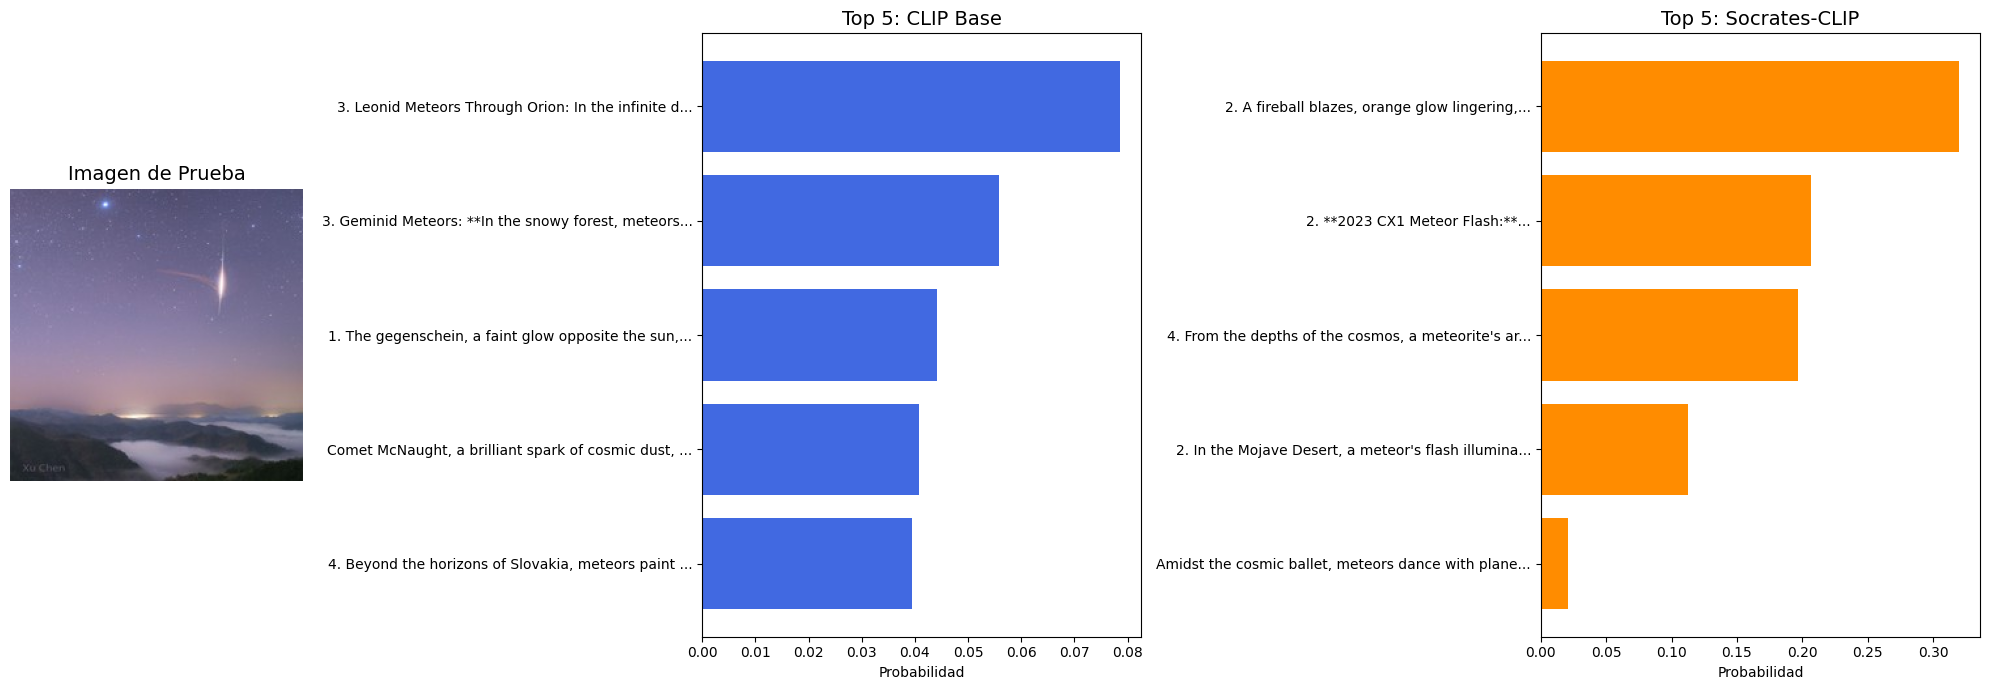

In [8]:
def compare_models(image_path, text_corpus, my_model_path, device="cuda" if torch.cuda.is_available() else "cpu"):
    model_base, preprocess = clip.load("ViT-B/32", device=device)
    
    model_socrates, _ = clip.load("ViT-B/32", device=device)
    model_socrates.load_state_dict(torch.load(my_model_path, map_location=device))
    
    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
    text_tokens = clip.tokenize(text_corpus, truncate=True).to(device)
    
    results = {}
    models = {"CLIP Base": model_base, "Socrates-CLIP": model_socrates}

    with torch.no_grad():
        for name, model in models.items():
            model.eval()
            img_feat = model.encode_image(image)
            txt_feat = model.encode_text(text_tokens)
            
            img_feat /= img_feat.norm(dim=-1, keepdim=True)
            txt_feat /= txt_feat.norm(dim=-1, keepdim=True)
            
            probs = (100.0 * img_feat @ txt_feat.T).softmax(dim=-1).cpu().numpy()[0]
            
            top5_idx = probs.argsort()[-5:][::-1]
            results[name] = [(text_corpus[i], probs[i]) for i in top5_idx]

    fig, axes = plt.subplots(1, 3, figsize=(20, 7), gridspec_kw={'width_ratios': [1, 1.5, 1.5]})
    
    axes[0].imshow(Image.open(image_path))
    axes[0].set_title("Imagen de Prueba", fontsize=14)
    axes[0].axis('off')
    
    for i, (name, top_preds) in enumerate(results.items()):
        ax = axes[i+1]
        texts = [p[0][:50] + "..." for p in top_preds]
        print([p[0][:100] for p in top_preds])
        scores = [p[1] for p in top_preds]
        
        ax.barh(range(5), scores, color='royalblue' if "Base" in name else 'darkorange')
        ax.set_yticks(range(5))
        ax.set_yticklabels(texts)
        ax.invert_yaxis()
        ax.set_title(f"Top 5: {name}", fontsize=14)
        ax.set_xlabel("Probabilidad")

    plt.tight_layout()
    plt.show()

corpus = list(test_df['phil_caption']) 
compare_models("apod_images_224/2026-01-12.jpg", corpus, "socrates_clip_weights.pt")

In [40]:
def evaluate_human_alignment(text_query, image_paths, my_model_path, device="cuda" if torch.cuda.is_available() else "cpu"):

    print("-> Cargando modelos en memoria...")
    model_base, preprocess = clip.load("ViT-B/32", device=device)
    
    model_socrates, _ = clip.load("ViT-B/32", device=device)
    model_socrates.load_state_dict(torch.load(my_model_path, map_location=device))
    
    text_tokens = clip.tokenize([text_query], truncate=True).to(device)
    
    print(f"-> Procesando {len(image_paths)} imágenes del espacio exterior...")
    imgs_tensor = torch.cat([preprocess(Image.open(p)).unsqueeze(0) for p in image_paths]).to(device)
    
    results = {}
    models = {"CLIP Base": model_base, "Socrates-CLIP": model_socrates}
    
    with torch.no_grad():
        for name, model in models.items():
            model.eval()
            
            img_feats = model.encode_image(imgs_tensor)
            txt_feat = model.encode_text(text_tokens)
            
            img_feats /= img_feats.norm(dim=-1, keepdim=True)
            txt_feat /= txt_feat.norm(dim=-1, keepdim=True)
            
            logit_scale = model.logit_scale.exp().item()
            similarity = (logit_scale * txt_feat @ img_feats.T).squeeze(0)

            probs = similarity.softmax(dim=-1).cpu().numpy()
            
            top5_idx = probs.argsort()[-5:][::-1]
            results[name] = [(image_paths[idx], probs[idx]) for idx in top5_idx]
            

    fig = plt.figure(figsize=(22, 10))
    
    fig.suptitle(f'Frase: "{text_query}"', fontsize=18, fontweight='bold', y=1.02)
    

    subfigs = fig.subfigures(2, 1, hspace=0.1)
    
    for i, (model_name, top_matches) in enumerate(results.items()):
        subfigs[i].suptitle(model_name, fontsize=14, fontweight='semibold', 
                            color='royalblue' if "Base" in model_name else 'darkorange', x=0.08)
        
        axes = subfigs[i].subplots(1, 5)
        
        for rank, (img_path, score) in enumerate(top_matches):
            ax = axes[rank]
            img = Image.open(img_path)
            ax.imshow(img)
            
            base_name = os.path.basename(img_path)
            ax.set_title(f"Top {rank+1}\nConfianza: {score:.2%}", fontsize=11)
            ax.axis('off')
            
    plt.subplots_adjust(top=0.85)
    plt.show()

-> Cargando modelos en memoria...


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26440\2840339149.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_socrates.load_state_dict(torch.load(my_model_path, ma

-> Procesando 1077 imágenes del espacio exterior...


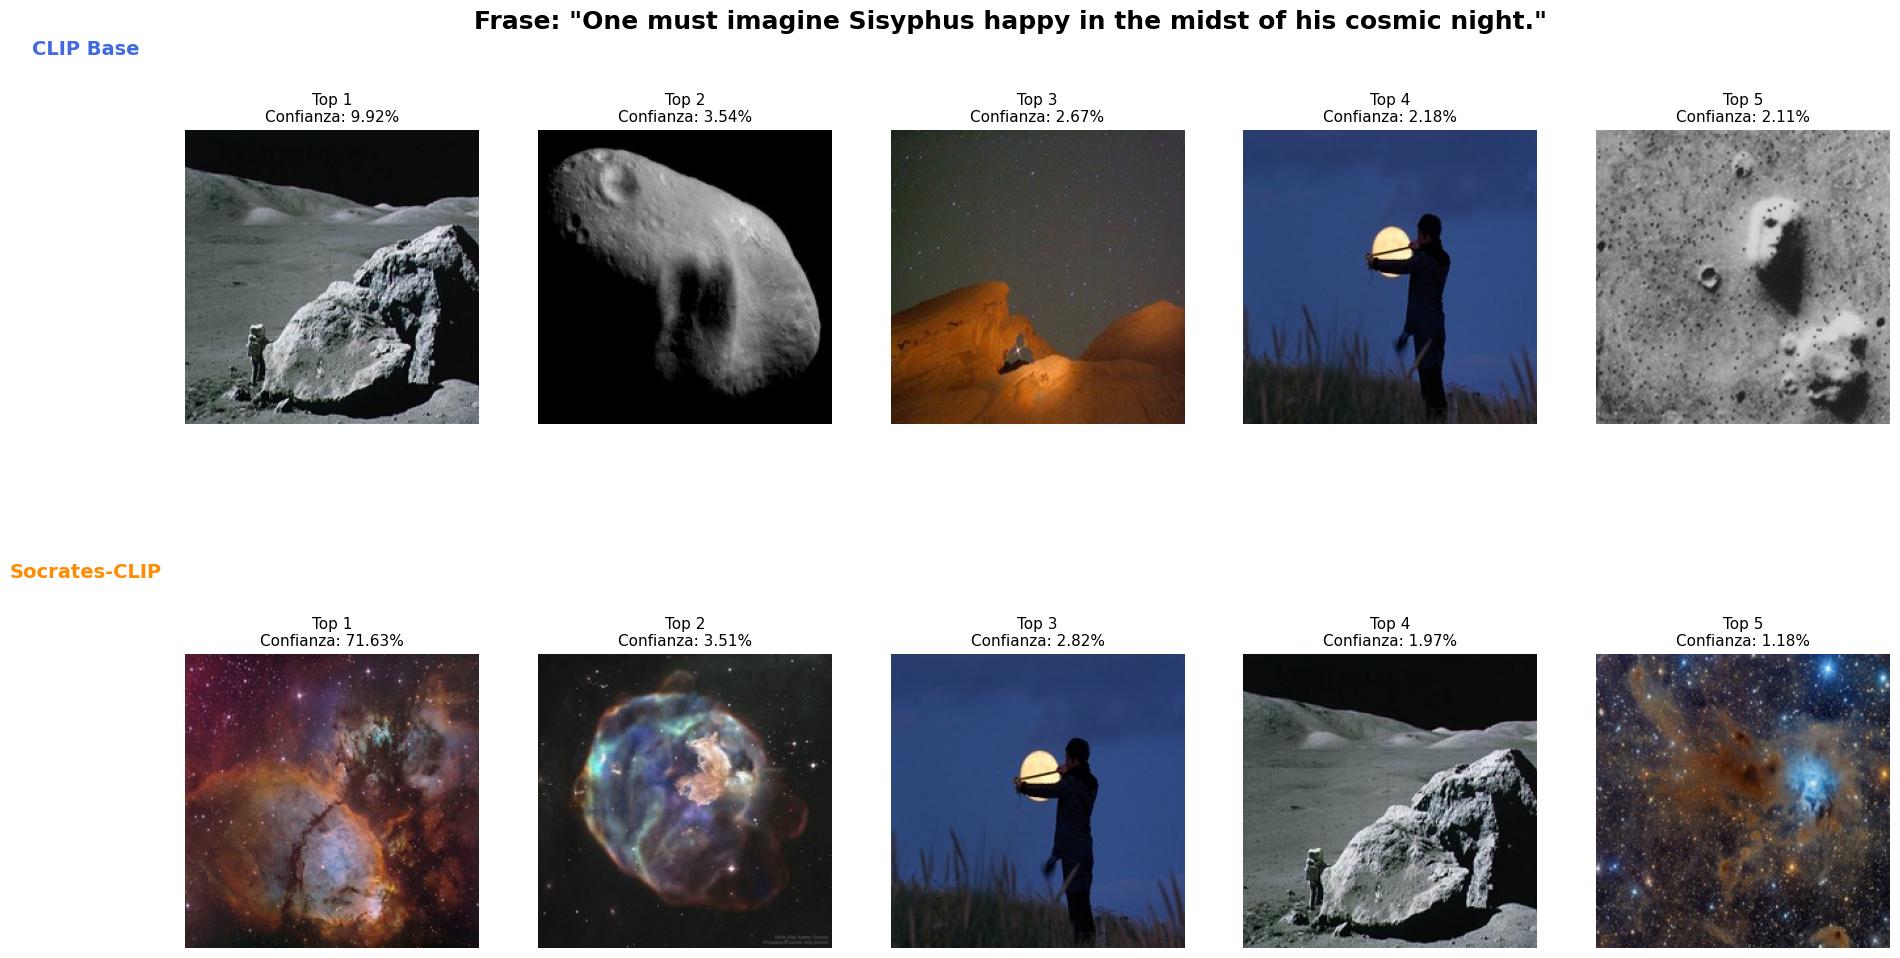

In [42]:
rutas_imagenes = test_df['image_path'].tolist()

frase_prueba = "One must imagine Sisyphus happy in the midst of his cosmic night."

evaluate_human_alignment(
    text_query=frase_prueba, 
    image_paths=rutas_imagenes, 
    my_model_path="socrates_clip_weights.pt"
)

-> Cargando modelos en memoria...


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26440\2840339149.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_socrates.load_state_dict(torch.load(my_model_path, ma

-> Procesando 1077 imágenes del espacio exterior...


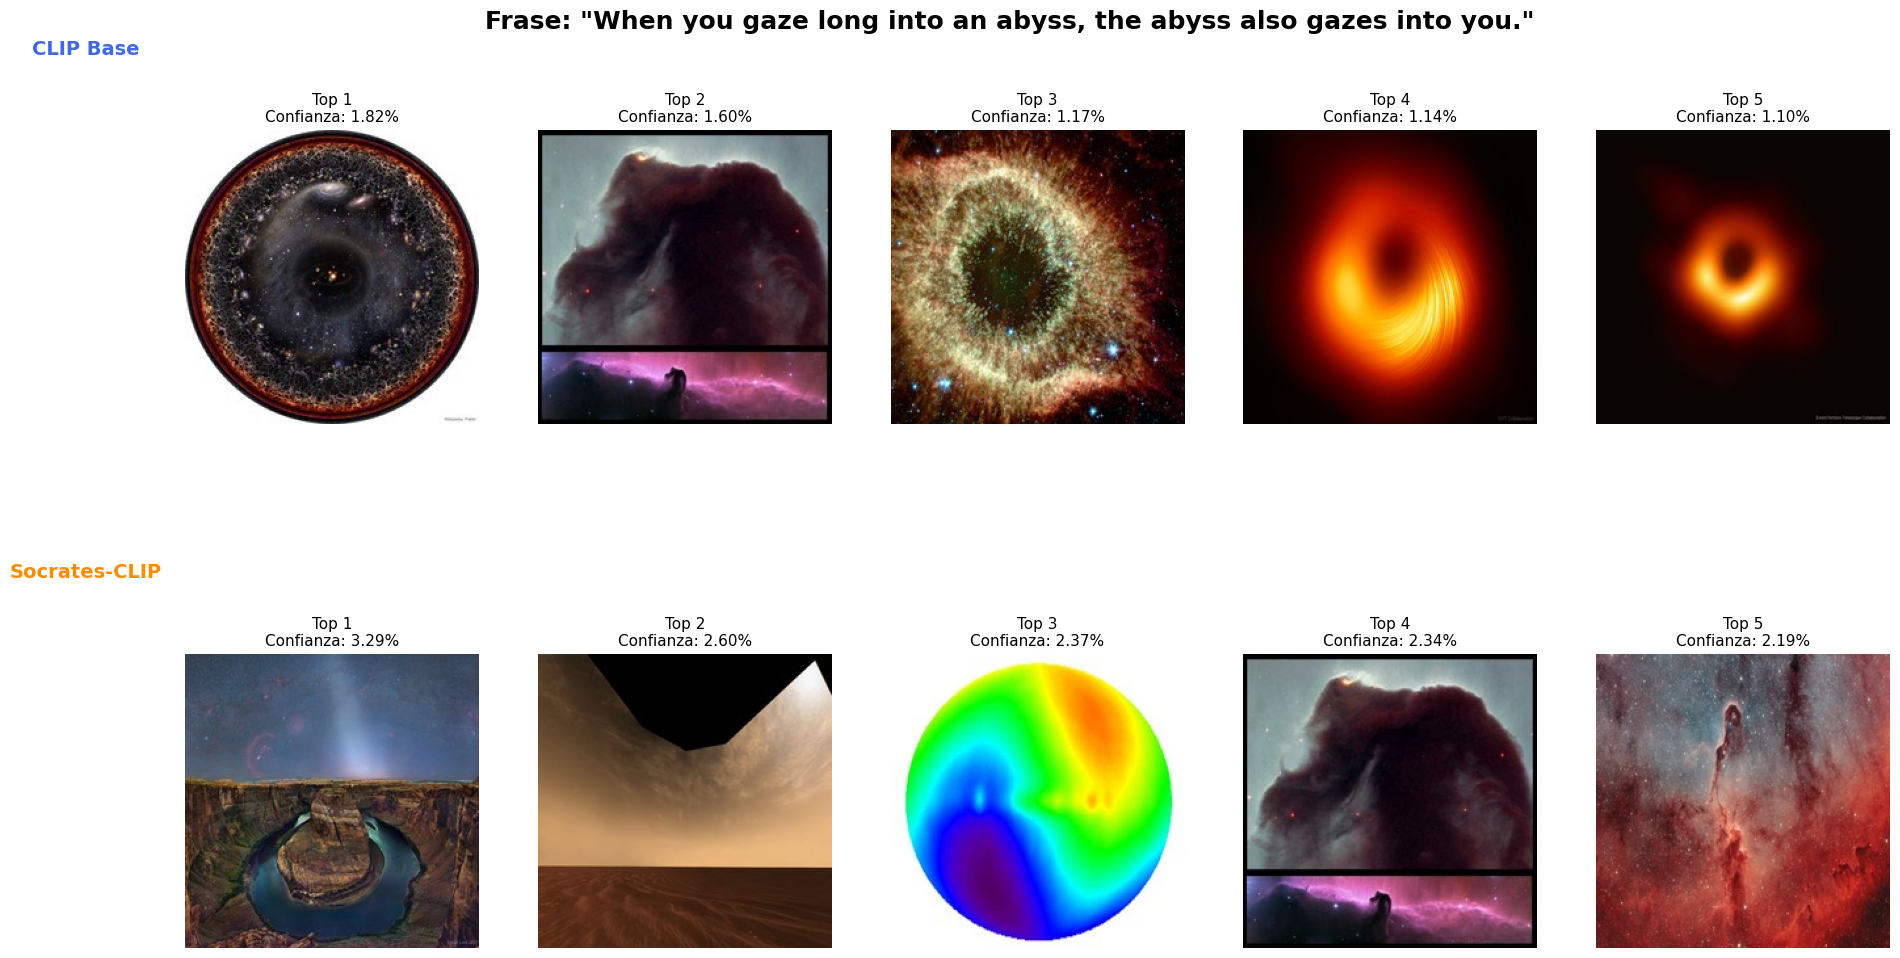

In [43]:
rutas_imagenes = test_df['image_path'].tolist()

frase_prueba = "When you gaze long into an abyss, the abyss also gazes into you."

evaluate_human_alignment(
    text_query=frase_prueba, 
    image_paths=rutas_imagenes, 
    my_model_path="socrates_clip_weights.pt"
)